# Introduction to Python Project : FoodHub Data Analysis

# Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.


# Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company improve its business.

# Data Dictionary

order_id: Unique ID of the order

customer_id: ID of the customer who ordered the food

restaurant_name: Name of the restaurant

cuisine_type: Cuisine ordered by the customer

cost_of_the_order: Cost of the order

day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)

rating: Rating given by the customer out of 5

food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.

delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# Importing necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Reading the data
data = pd.read_csv('/content/drive/MyDrive/foodhub_order.csv')

In [ ]:
# Viewing first 5 rows
data.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
print(f"There are {data.shape[0]} rows and {data.shape[1]} columns")

There are 1898 rows and 9 columns


#### Observations:
There are **1898 rows** and **9 columns**.

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:

*   There are 5 numerical columns in the data and 4 object type columns.

1.   float64
      
      cost_of_the_order
2.   int64
      
      order_id, customer_id, food_preparation_time, delivery_time
3.   object - string
      
      restaurant_name, cuisine_type, day_of_the_week, rating












### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
#checking missing values
data.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations:

There are **no missing values** in this data.

However, we can see there are values "Not Given" in "rating" column.












In [ ]:
#copying the rating column to rating_modified column and replacing Not given values with NaN
data['rating_modified'] = data['rating'].replace(['Not given'],np.nan)

# changing the data type of rating_modified to float
data['rating_modified'] = data['rating_modified'].astype(float)

*   Replacing 'Not given' with NaN.
*   Changing the data type of column 'rating' to numerical data type to see statistical data like percentile, mean, min, max.
*   Now there are 6 numerical columns and 3 object type columns


In [ ]:
#checking duplicate values
data.duplicated().sum()

0

No duplicate rows found

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00
rating_modified,1162.0,4.344234e+00,0.741478,3.00,4.00,5.00,5.000000e+00,5.00


#### Observations:


*   Minimum food preparation time is **20 minutes** while the maximum time it takes is **35 minutes**. Average food preparation time is **27 minutes**.



### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
data['rating_modified'].value_counts(dropna=False)

,count
rating_modified,
NaN,736
5.0,588
4.0,386
3.0,188


#### Observations:
**736 orders** are not rated

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

### **Observations on Cuisine Type**

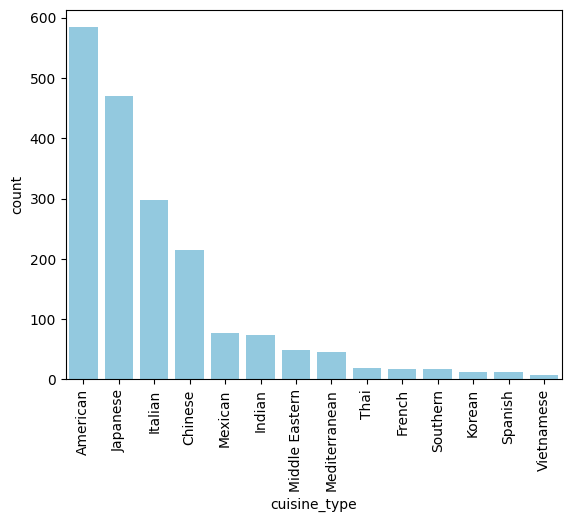

In [ ]:
sns.countplot(data=data, x = 'cuisine_type',color='skyblue',order=data['cuisine_type'].value_counts().index); #bar graph for cuisine type
plt.xticks(rotation= 90);
plt.show()

Out of the 14 cuisines, the number of orders for **American, Japanese, Italian, and Chinese** cuisines are significantly higher compared to the others.

### **Observations on Cost of the order**

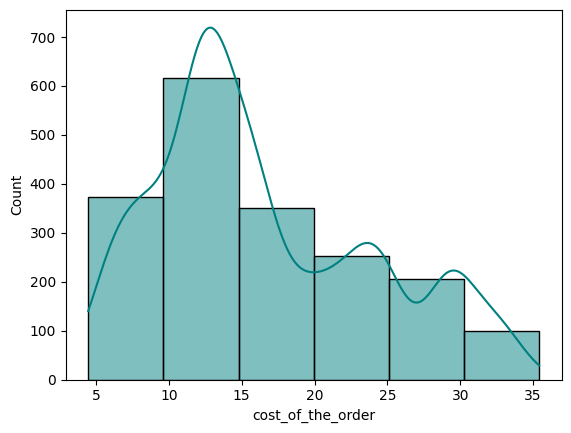

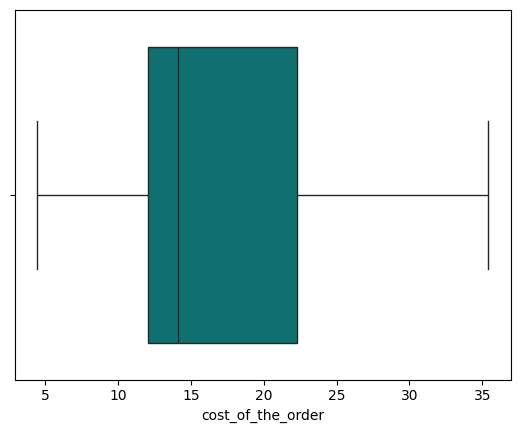

In [ ]:
sns.histplot(data=data,x='cost_of_the_order',bins=6,color='teal',kde=True) #Histogram for the cost of order
plt.show()
sns.boxplot(data=data,x='cost_of_the_order',color='teal') #Boxplot for the cost of order.
plt.show()

The distribution is **right-skewed**.

The majority of orders are relatively inexpensive, with only a few orders being significantly higher in cost. 70 % of the orders are priced below 20 dollars.

The average cost is 16 dollars whereas majority of the orders cost between 10-15 dollars.

There are **no outliers** present.

### **Observations on Day of the week**

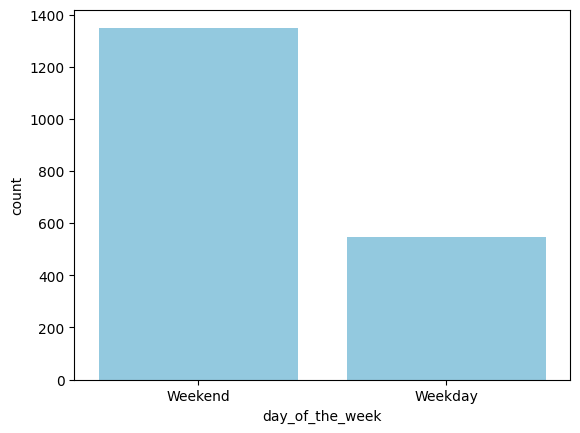

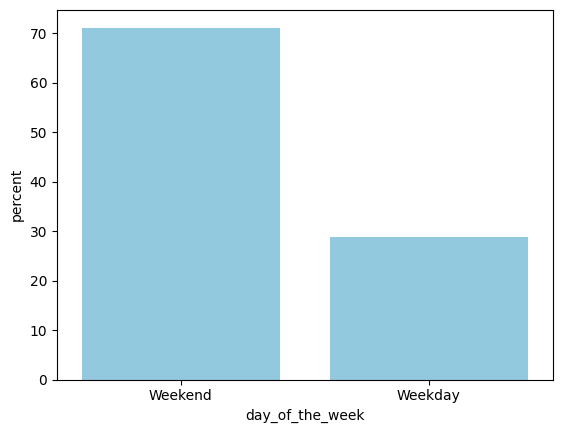

In [ ]:
sns.countplot(data=data, x = 'day_of_the_week',color='skyblue'); #bar graph for day of the week
plt.show()

sns.countplot(data=data, x = 'day_of_the_week',color='skyblue',stat='percent'); #analysing percentage
plt.show()

There are **more number of orders on the weekend** than the weekdays.
About 70% of the orders are made on weekends.

### **Observations on Rating**

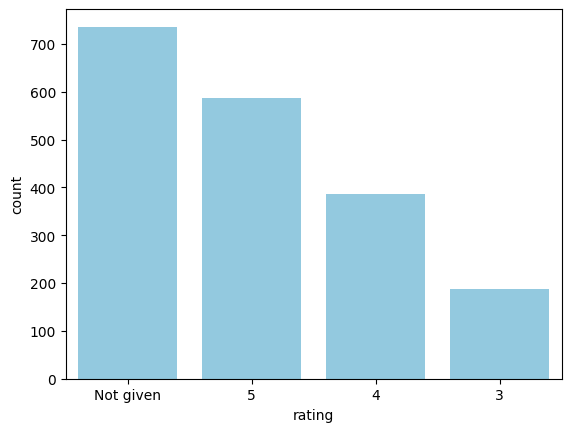

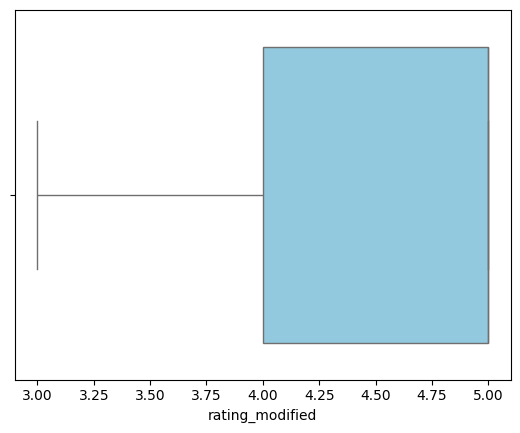

In [ ]:
sns.countplot(data = data, x = 'rating',color='skyblue',order=['Not given', '5', '4', '3']); # countplot of rating
plt.show()
sns.boxplot(data=data,x='rating_modified',color='skyblue') # Boxplot for the rating.
plt.show()

**736 orders do not have rating**, which constitutes about 40% of the total orders.

Out of the 1162 orders that are rated, **75% of the orders are rated 4 or above**.

### **Observations on Food Preparation Time**

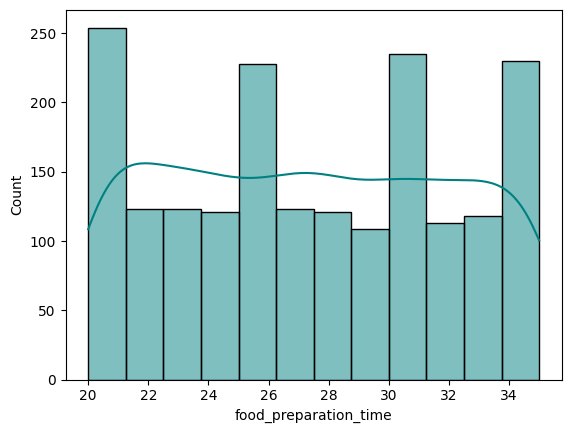

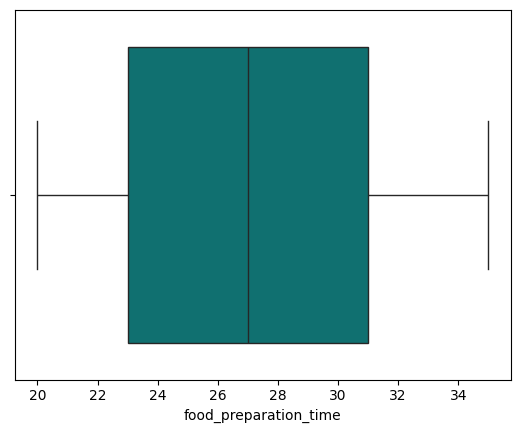

In [ ]:
sns.histplot(data=data,x='food_preparation_time',color='teal',kde=True) #Histogram for the food preparation time.
plt.show()
sns.boxplot(data=data,x='food_preparation_time',color='teal') #Boxplot for the food preparation time.
plt.show()

The average food preparation time is **27 minutes**.

The **mean and median are equal for food preparation time**. However there is no bell curve, so it cannot be considered as a normal distribution. Since it has multiple modes, it can be termed as **multimodal distribution**.

### **Observations on Food delivery time**

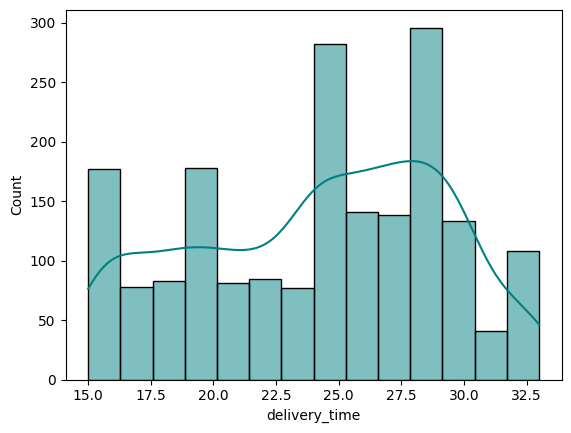

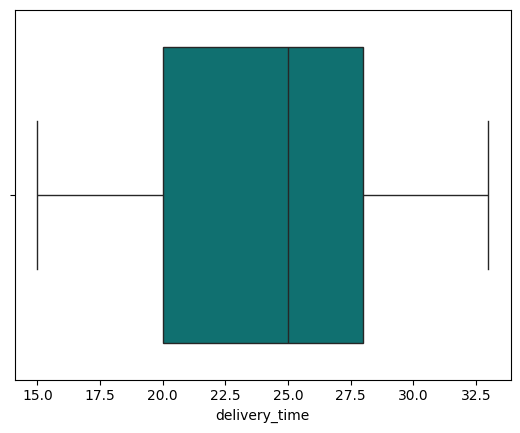

In [ ]:
sns.histplot(data=data,x='delivery_time',kde=True,color='teal') #Histogram for the food delivery time.
plt.show()
sns.boxplot(data=data,x='delivery_time',color='teal')
plt.show()

Food delivery time is **slightly left-skewed**.

There are **no outliers**.


### **Observations on Restaurant**

In [ ]:
data['restaurant_name'].nunique()

178

There is a total of **178 unique restaurants**.

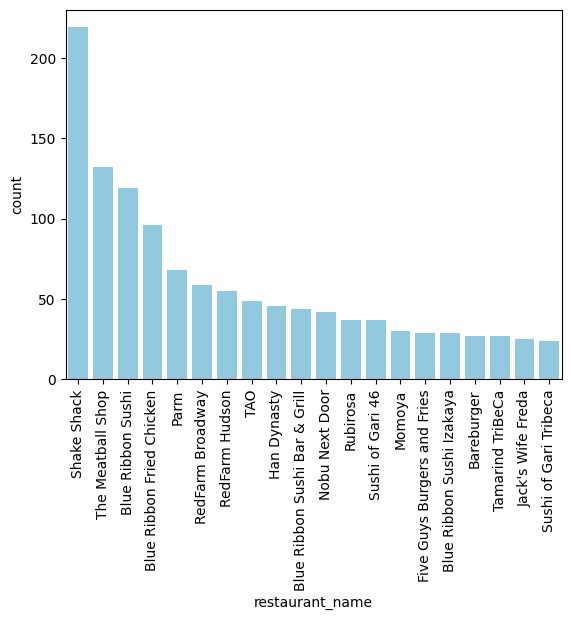

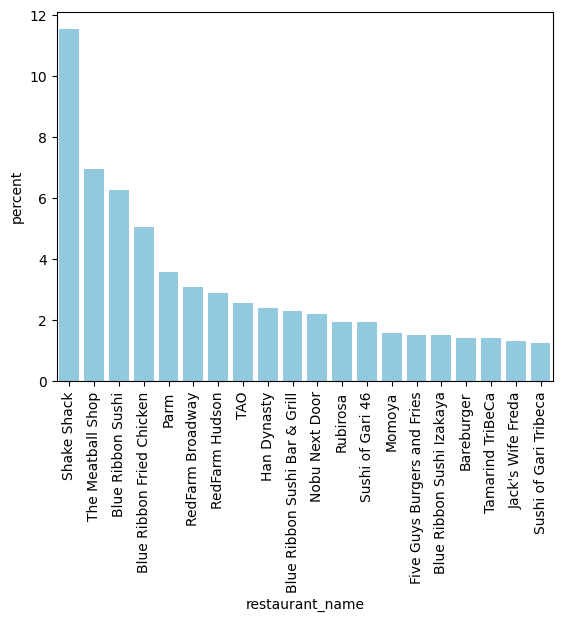

In [ ]:
#Analysing top 20 restaurants which recieved high number of orders
sns.countplot(data=data, x = 'restaurant_name', order=data['restaurant_name'].value_counts().iloc[:20].index,color='skyblue');
plt.xticks(rotation= 90);
plt.show()

#Analysing the percentage
sns.countplot(data=data, x = 'restaurant_name', order=data['restaurant_name'].value_counts().iloc[:20].index,color='skyblue',stat='percent');
plt.xticks(rotation= 90);
plt.show()

The top restaurant in terms of number of orders placed is **Shake Shack** followed by **The Meatball Shop, Blue Ribbon Sushi and Blue Ribbon Fried Chicken**.

The top 15 restaurants account for more than 50% of the total orders

### **Observations on Customer**

In [ ]:
#getting the count of orders by each customer
arr=data['customer_id'].value_counts()
arr1=pd.DataFrame(arr)
#analysing how many customers are placing only one order in the app
arr1.value_counts().rename_axis('number of orders').reset_index(name='number of customers')

,number of orders,number of customers
0,1,784
1,2,267
2,3,83
3,4,33
4,5,19
5,6,6
6,7,4
7,8,1
8,9,1
9,10,1


**65% of the customers** have placed **only one order**.



### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
data['restaurant_name'].value_counts().head(5)

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:
The top 5 restaurants in terms of the number of orders received are **Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken and Parm**.

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
data[data['day_of_the_week']=='Weekend']['cuisine_type'].value_counts()

,count
cuisine_type,
American,415
Japanese,335
Italian,207
Chinese,163
Mexican,53
Indian,49
Mediterranean,32
Middle Eastern,32
Thai,15


#### Observations:
The most popular cuisine on weekends is **American** followed by Japanese and Italian.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
data[data['cost_of_the_order']>20].shape[0]/data.shape[0]*100

29.24130663856691

#### Observations:
29.24% of the orders cost more than 20 dollars.

### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
data['delivery_time'].mean()

24.161749209694417

#### Observations:
The mean delivery time is **24.16 minutes**

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
data['customer_id'].value_counts().head(3)

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations:
The IDs of top 3 most frequent customers are **52832, 47440 and 83287**. The number of orders they have placed are **13,10 and 9** respectively.

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


### **Relationship between Cost of the order, Food preparation time and Delivery time**

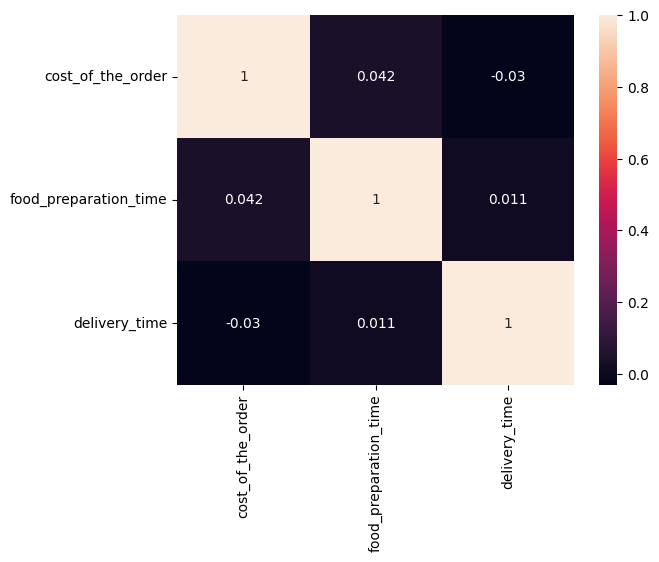

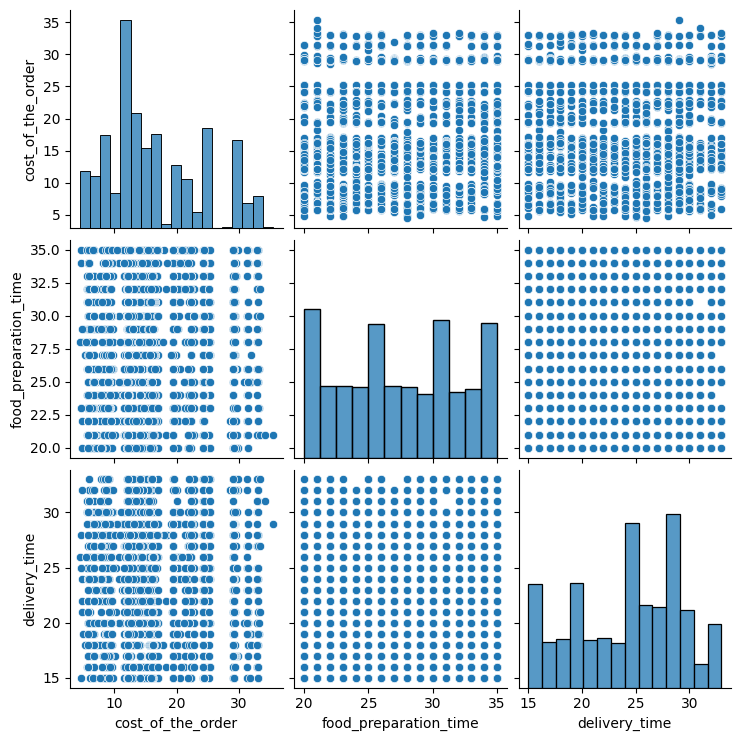

In [ ]:
#Analysing correlation between the numerical values with heatmap
sns.heatmap(data[['cost_of_the_order', 'food_preparation_time', 'delivery_time']].corr(), annot=True)
plt.show()

#Analysing correlation between the numerical values with pairplot
sns.pairplot(data = data[['cost_of_the_order', 'food_preparation_time', 'delivery_time']])
plt.show()

Cost of the order, food preparation time and delivery time **do not show any correlation**.

**Relationship between Cuisine type and Cost of the order**

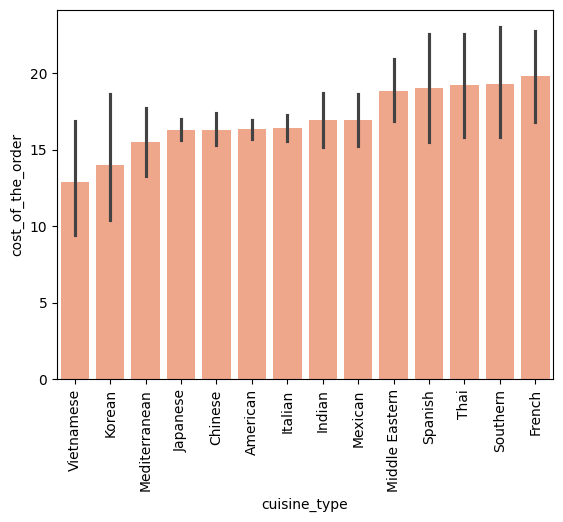

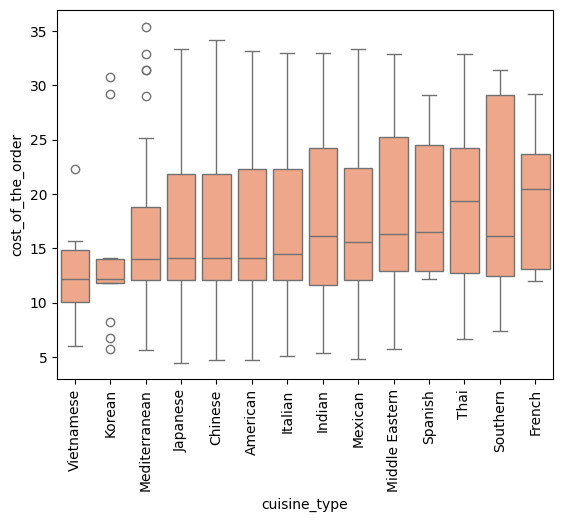

In [ ]:
#Plotting average cost of the order of each cuisine in ascending order
sns.barplot(data = data, x = 'cuisine_type', y = 'cost_of_the_order',order=data.groupby('cuisine_type')['cost_of_the_order'].mean().sort_values().index,color='lightsalmon')
plt.xticks(rotation=90)
plt.show()
sns.boxplot(data=data,x='cuisine_type',y='cost_of_the_order',order=data.groupby('cuisine_type')['cost_of_the_order'].mean().sort_values().index,color='lightsalmon')
plt.xticks(rotation=90)
plt.show()

**Vietnamese, Korean and Mediterranean cuisines are relatively less expensive than other cuisines**. However, there are **outliers observed** in all these 3 cuisines. There is a Korean order costing as low as 5 dollars as well as 31 dollars. Few Mediterranean orders cost above 30 dollars. Interesting to note that the most expensive order belongs to Meditteranean cuisine.

**French, Southern and Thai** cuisines are **relatively more expensive** than other cuisines. In fact, 75% of orders from these cuisines exceed the average cost of all orders.

### **Relationship between Restaurant and Cost of the order**


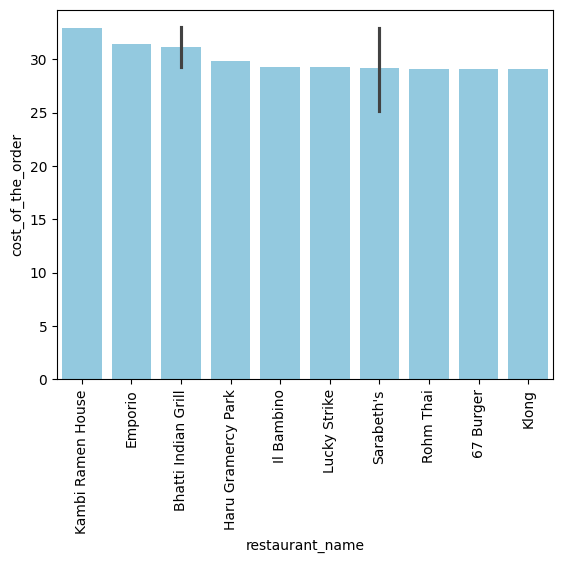

In [ ]:
#analysing top 10 restaurants with the highest average cost of the order
sns.barplot(data = data, x = 'restaurant_name', y = 'cost_of_the_order', order = data.groupby('restaurant_name')['cost_of_the_order'].mean().nlargest(10).index,color='skyblue')
plt.xticks(rotation=90)
plt.show()

The restaurants with **highest average cost of the order** are Kambi Ramen House, Emporio and Bhatti Indian Grill.

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 140 (\x8c) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


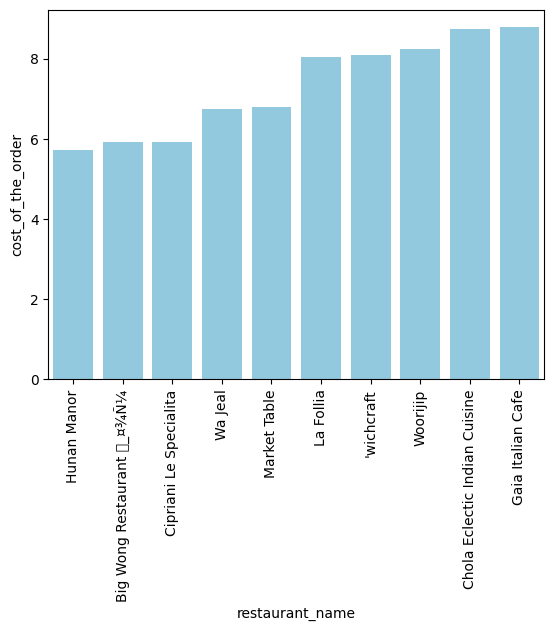

In [ ]:
#analysing top 10 restaurants with the least average cost of the order
sns.barplot(data = data, x = 'restaurant_name', y = 'cost_of_the_order', order = data.groupby('restaurant_name')['cost_of_the_order'].mean().nsmallest(10).index,color='skyblue')
plt.xticks(rotation=90)
plt.show()

The restaurants with **lowest average cost of the order** are Hunan Manor, Big Wong Restaurant and Cipriani Le Specialita.

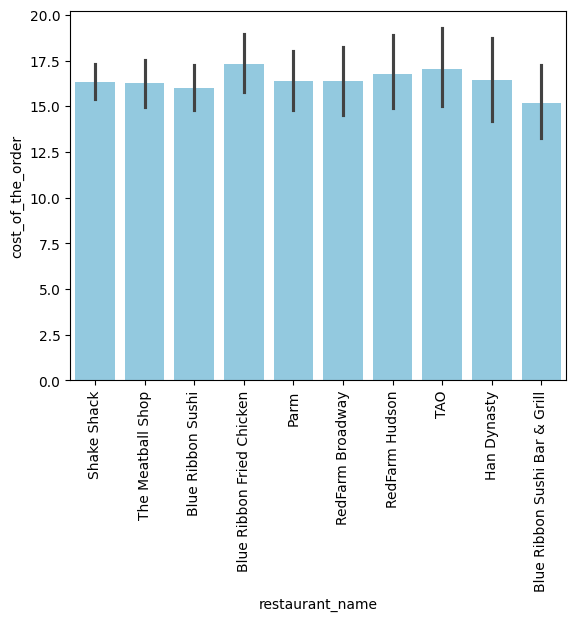

In [ ]:
#Analysing the average cost of the order of the 10 restaurants that received most number of orders
sns.barplot(data = data, x = 'restaurant_name', y = 'cost_of_the_order', order = data.restaurant_name.value_counts().iloc[:10].index,color='skyblue')
plt.xticks(rotation=90)
plt.show()

On an average, the cost of food in the top 10 most ordered restaurants is **above 15 dollars**.

### **Relationship between Cuisine type and Rating**

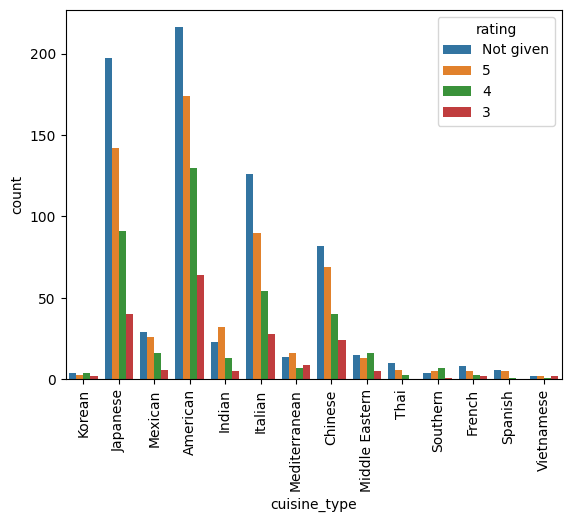

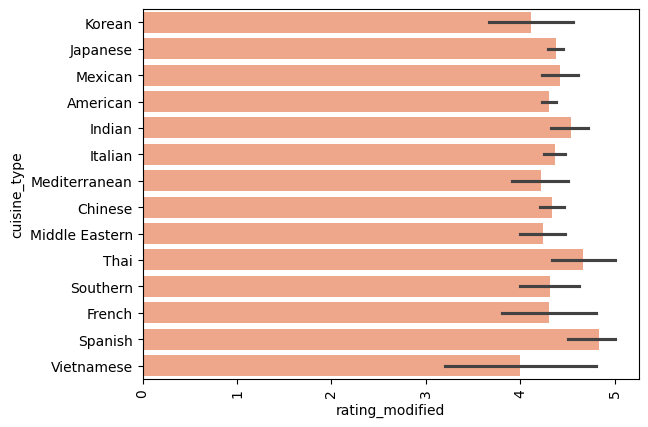

In [ ]:
#Analysing the cuisine type and corresponding average ratings
sns.countplot(data = data, x = 'cuisine_type', hue = 'rating',hue_order=['Not given','5','4','3'])
plt.xticks(rotation=90)
plt.show()
#Analysing the cuisine type and corresponding average ratings with the 'rating_modified' column.
#This will ignore the 'Not given' values and analyses only the rating provided.
sns.barplot(data = data, x = 'rating_modified', y = 'cuisine_type',color='lightsalmon')
plt.xticks(rotation=90)
plt.show()

Spanish cuisine has got the **highest mean rating** followed by Thai and Indian.

### **Relationship between Restaurant and Rating**

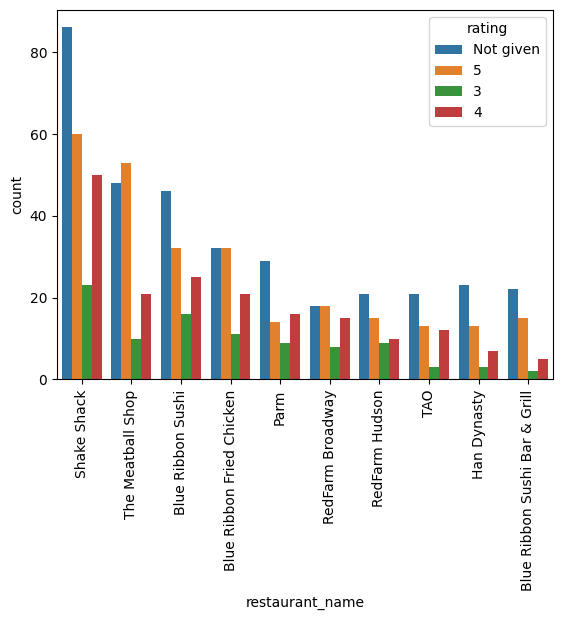

In [ ]:
#Analysing the rating of top 10 restaurants which received most number of orders
sns.countplot(data = data, x = 'restaurant_name', hue = 'rating', order = data.restaurant_name.value_counts().iloc[:10].index)
plt.xticks(rotation=90)
plt.show()

Many orders are not rated. Out of the given ratings, most restaurants have got **rating 4 or 5**.

### **Relationship between Restaurant and Day of the week**

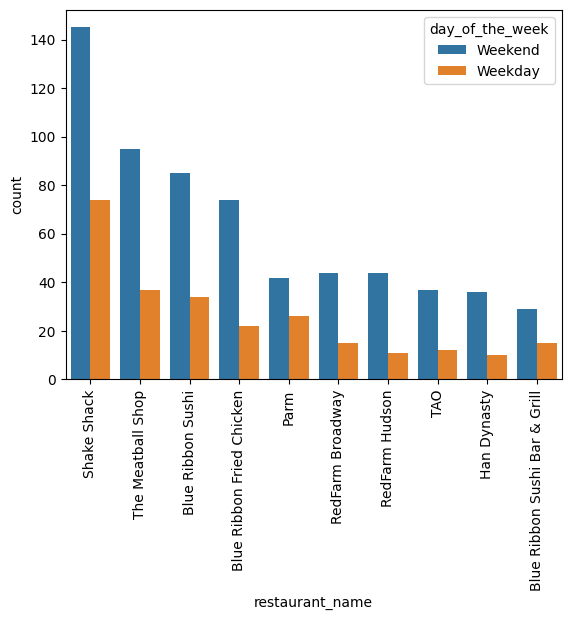

In [ ]:
#Analysing the difference in the number of orders during the weekday and weekend in the top 10 restaurants that received most number of orders
sns.countplot(data = data, x = 'restaurant_name', hue = 'day_of_the_week', order = data.restaurant_name.value_counts().iloc[:10].index)
plt.xticks(rotation=90)
plt.show()

All the top 10 restaurants receiving highest number of orders receive **more orders on weekends than weekdays**.

In [ ]:
# Group the data by 'restaurant_name' and 'day_of_the_week' columns and then count the occurrences of 'restaurant_name' in each group
# After that, unstack the result to pivot the 'day_of_the_week' into columns and fill missing values with 0 where there is no data for a specific day of the week
order_counts = data.groupby(['restaurant_name', 'day_of_the_week'])['restaurant_name'].count().unstack(fill_value=0)
#Checking the restaurants which received more number of orders on weekdays than weekends
order_counts[order_counts['Weekday'] > order_counts['Weekend']]


day_of_the_week,Weekday,Weekend
restaurant_name,,
'wichcraft,1,0
67 Burger,1,0
Amy Ruth's,2,1
Anjappar Chettinad,1,0
Balade,1,0
Big Wong Restaurant _¤¾Ñ¼,1,0
Carmine's,2,1
Dig Inn Seasonal Market,1,0
Dirty Bird to Go,3,1


Out of 178 restaurants, only 27 restaurants are **receiving more orders on weekdays than the weekends**.

### **Relationship between Cuisine type and Day of the week**



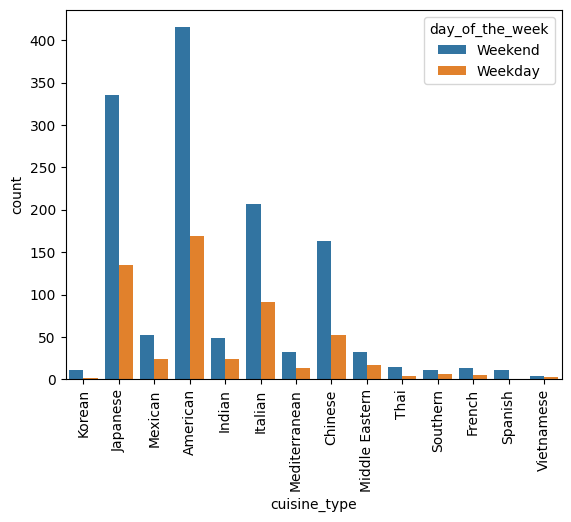

In [ ]:
#Analysing the difference of number orders for each cuisine during weekdays and weekends
sns.countplot(data = data, x = 'cuisine_type', hue = 'day_of_the_week')
plt.xticks(rotation=90)
plt.show()

Irrecspective of the day of the week, **American, Japanese and Italian** remain the most popular cuisines.

All the cuisines are ordered more on weekends than weekdays.

### **Relationship between Day of the Week and Food preparation time**

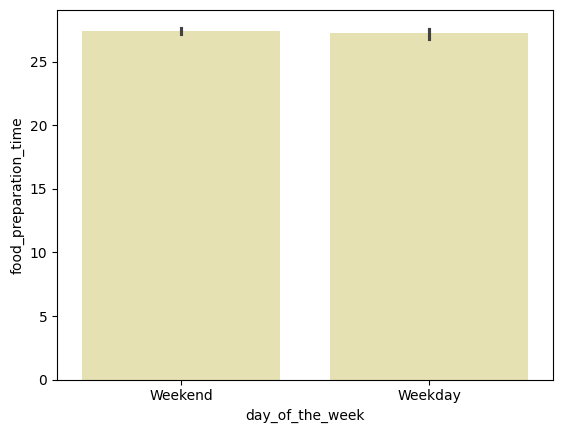

In [ ]:
#Analysing difference in the food preparation time during weekdays and weekends
sns.barplot(data = data, x = 'day_of_the_week', y = 'food_preparation_time',color='palegoldenrod')
plt.show()

There is no major difference in the food preparation time in weekdays and weekends.

### **Relationship between Day of the week and Delivery time**

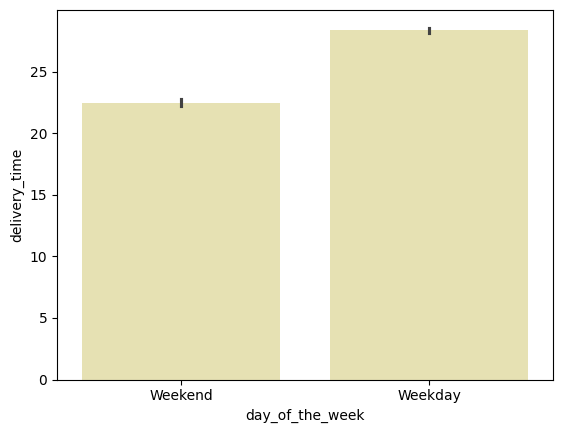

In [ ]:
#Analysing difference in the food delivery time during weekdays and weekends
sns.barplot(data = data, x = 'day_of_the_week', y = 'delivery_time',color='palegoldenrod')
plt.show()

**Weekend delivery is faster** than weekdays.

### **Relationship between Day of the week and Cost of the order**

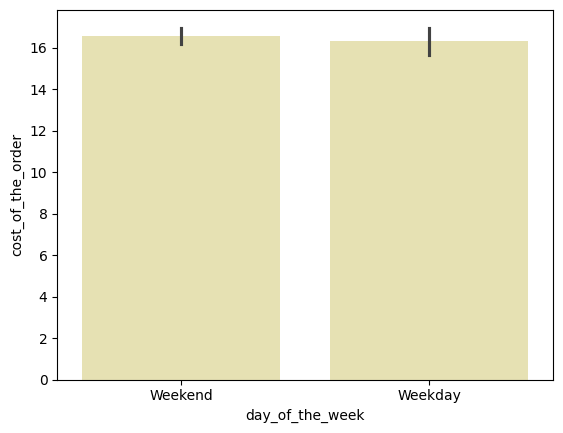

In [ ]:
#Analysing difference in the cost of the order during weekdays and weekends
sns.barplot(data = data, x = 'day_of_the_week', y = 'cost_of_the_order',color='palegoldenrod')
plt.show()

The **average cost of the order is slightly higher on weekends**.

### **Relationship between Restaurant and Food prepartion time**

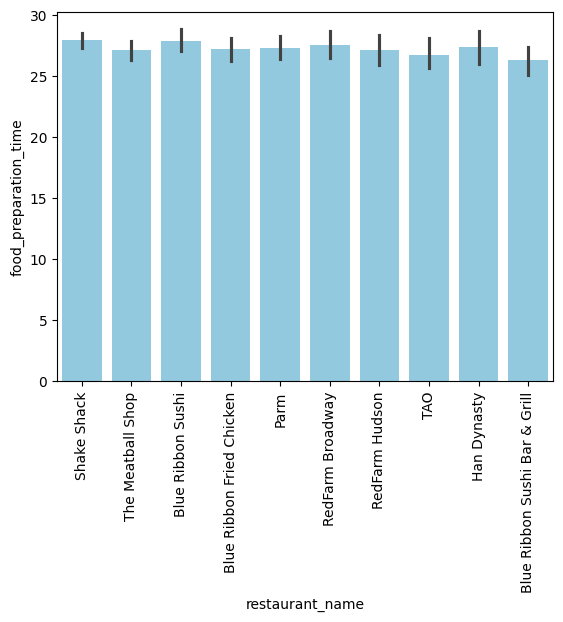

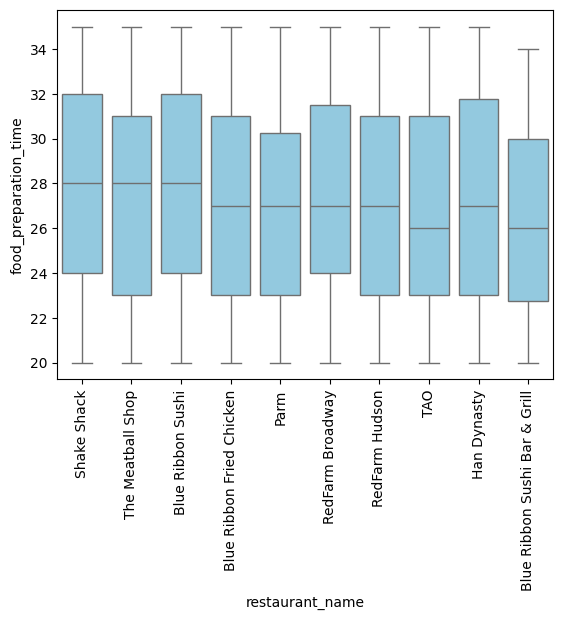

In [ ]:
#Analysing the average food preparation in the top 10 restaurants that received most number of orders
sns.barplot(data = data, x = 'restaurant_name', y = 'food_preparation_time', order = data.restaurant_name.value_counts().iloc[:10].index,color='skyblue')
plt.xticks(rotation=90)
plt.show()

sns.boxplot(data=data,x='restaurant_name',y='food_preparation_time',order=data.restaurant_name.value_counts().iloc[:10].index,color='skyblue')
plt.xticks(rotation=90)
plt.show()

The **average food preparation time** for the top 10 most ordered restaurants is **more than 25 minutes**.

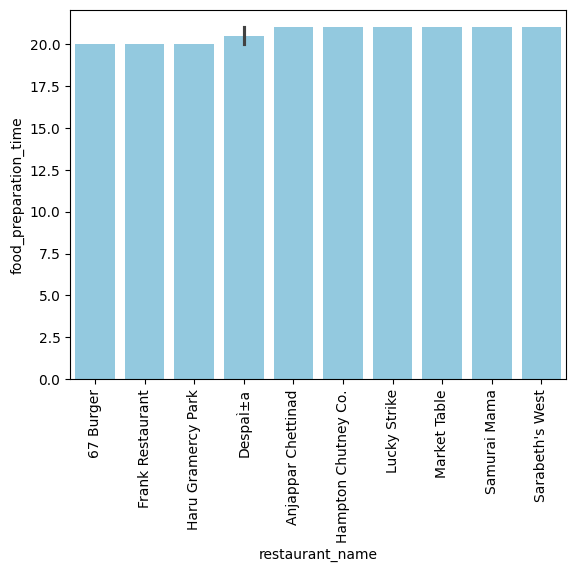

In [ ]:
#Plotting the restaurants that have the least food preparation time
sns.barplot(data = data, x = 'restaurant_name', y = 'food_preparation_time', order = data.groupby('restaurant_name')['food_preparation_time'].mean().nsmallest(10).index,color='skyblue')
plt.xticks(rotation=90)
plt.show()

The **restaurants which prepares the food the fastest** are **67 Burger, Frank Restaurant** and **Haru Gramercy Park**.

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 140 (\x8c) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


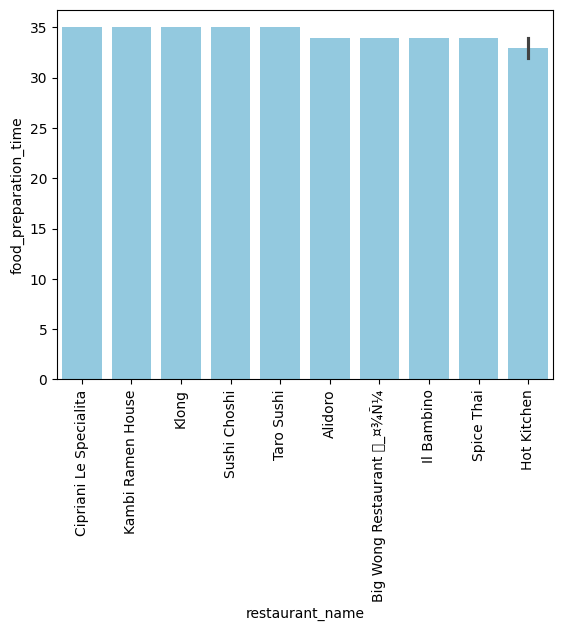

In [ ]:
#Plotting the restaurants that have the most food preparation time
sns.barplot(data = data, x = 'restaurant_name', y = 'food_preparation_time', order = data.groupby('restaurant_name')['food_preparation_time'].mean().nlargest(10).index,color='skyblue')
plt.xticks(rotation=90)
plt.show()


Food preparation time is the longest in the following restaurants: **Cipriani Le Specialita, Kambi Ramen House, Klong, Sushi Choshi and Taro Sushi**

### **Relationship between Restaurant and Delivery time**

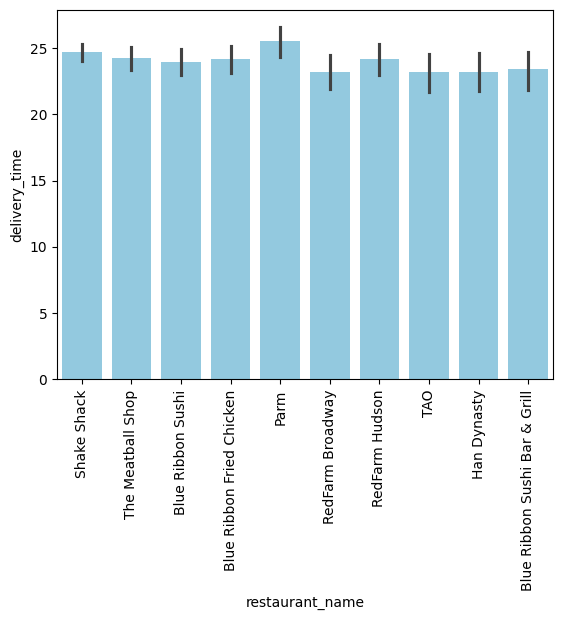

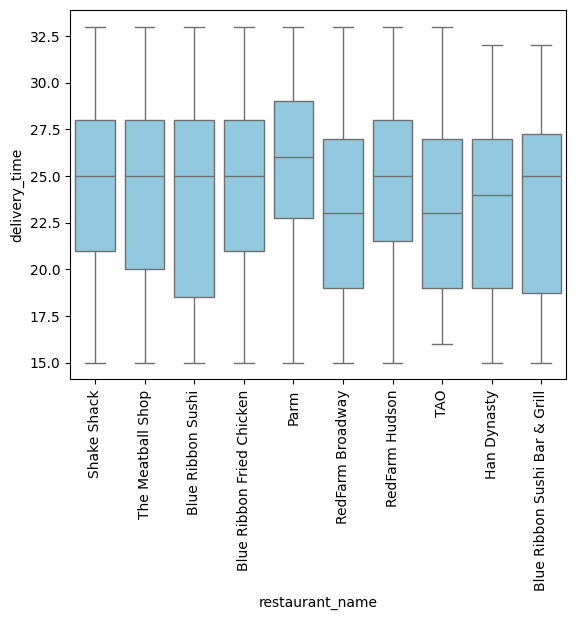

In [ ]:
#Plotting the top 10 restaurants with their respective food delivery time
sns.barplot(data = data, x = 'restaurant_name', y = 'delivery_time', order = data.restaurant_name.value_counts().iloc[:10].index,color='skyblue')
plt.xticks(rotation=90)
plt.show()

sns.boxplot(data=data,x='restaurant_name',y='delivery_time',order=data.restaurant_name.value_counts().iloc[:10].index,color='skyblue')
plt.xticks(rotation=90)
plt.show()

The delivery time ranges between **15 minutes to 33 minutes**.

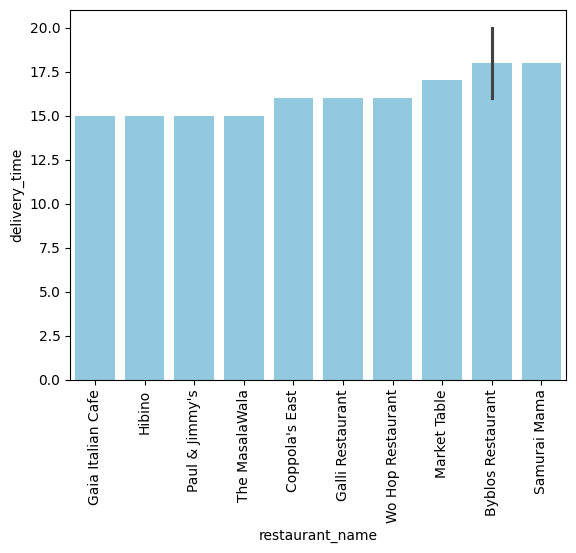

In [ ]:
#Plotting the restaurants that have the least food delivery time
sns.barplot(data = data, x = 'restaurant_name', y = 'delivery_time', order = data.groupby('restaurant_name')['delivery_time'].mean().nsmallest(10).index,color='skyblue')
plt.xticks(rotation=90)
plt.show()

The **restaurants which deliver the fastest** are **Gaia Italian Cafe, Hibino, Paul&Jimmy's** and **The MasalaWala**, the delivery time is only **15 minutes**.

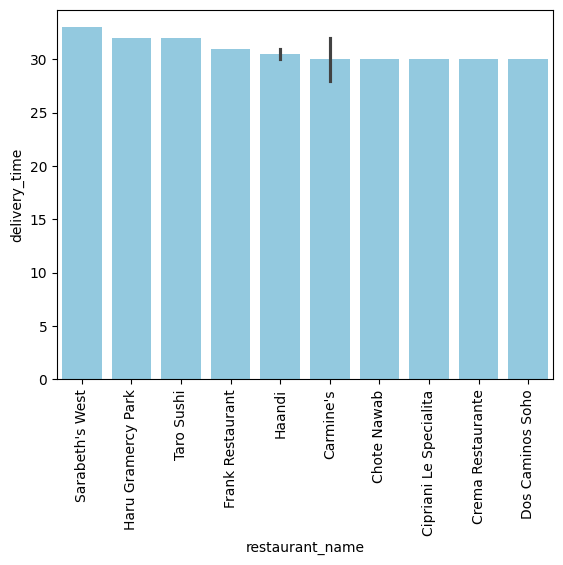

In [ ]:
#Plotting the restaurants that have the highest food delivery time
sns.barplot(data = data, x = 'restaurant_name', y = 'delivery_time', order = data.groupby('restaurant_name')['delivery_time'].mean().nlargest(10).index,color='skyblue')
plt.xticks(rotation=90)
plt.show()

The restaurants with the slowest delivery times (more than 30 minutes) are **Sarabeth's West, Haru Gramercy Park and Taro Sushi**.

Interesting to note that food is prepared faster in Haru Gramercy Park restaurant but takes a long time to deliver.

### **Relationship between Cuisine type and Food preparation time**

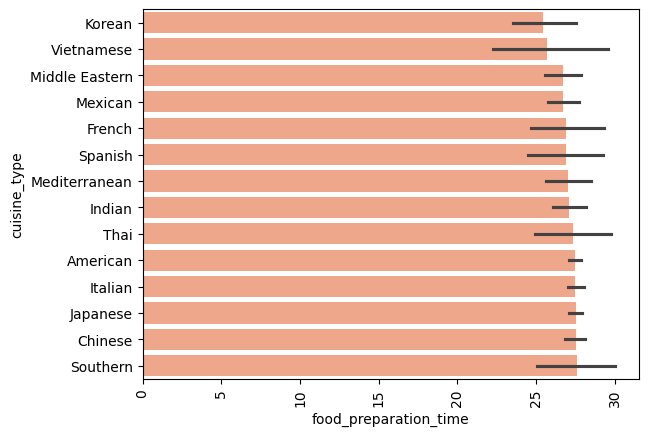

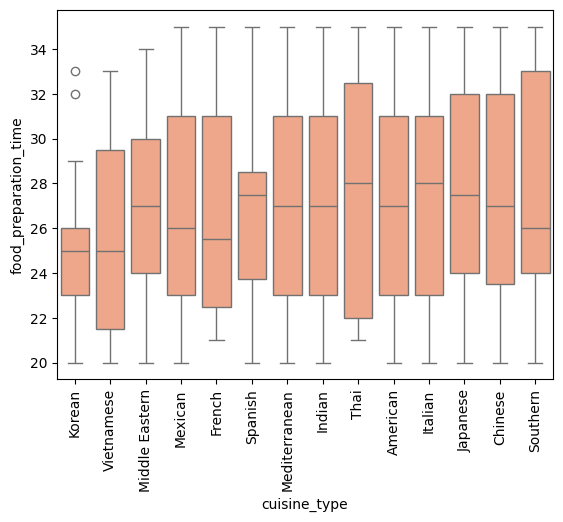

In [ ]:
#Plotting the cusine types with their respective food preparation time
sns.barplot(data=data,x='food_preparation_time',y='cuisine_type',order=data.groupby('cuisine_type')['food_preparation_time'].mean().sort_values().index,color='lightsalmon')
plt.xticks(rotation=90)
plt.show()

sns.boxplot(data=data,x='cuisine_type',y='food_preparation_time',order=data.groupby('cuisine_type')['food_preparation_time'].mean().sort_values().index,color='lightsalmon')
plt.xticks(rotation=90)
plt.show()

The cuisines that are cooked faster are **Korean and Vietnamese** followed by **Middle Eastern**. While the average food preperation time is the least for Korean cuisine among other cuisines, we can see that few Korean dishes take more than 30 minutes to prepare.

**Southern** cuisine takes the longest time to cook, followed by **Chinese and Japanese**.

### **Relationship between Restaurant, Food preparation time and Day of the week**

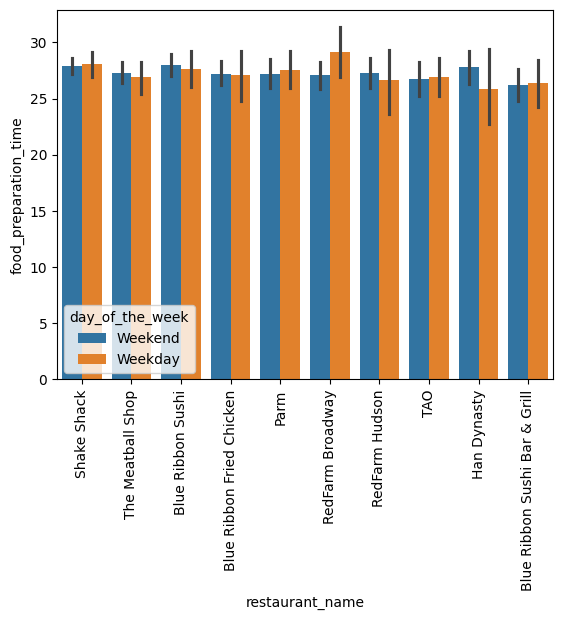

In [ ]:
sns.barplot(data = data, x = 'restaurant_name', y='food_preparation_time', hue = 'day_of_the_week', order = data.restaurant_name.value_counts().iloc[:10].index)
plt.xticks(rotation=90)
plt.show()

There is no significant pattern seen in food preparation time over the weekends and weekdays.

### **Relationship between Restaurant, Delivery time and Day of the week**

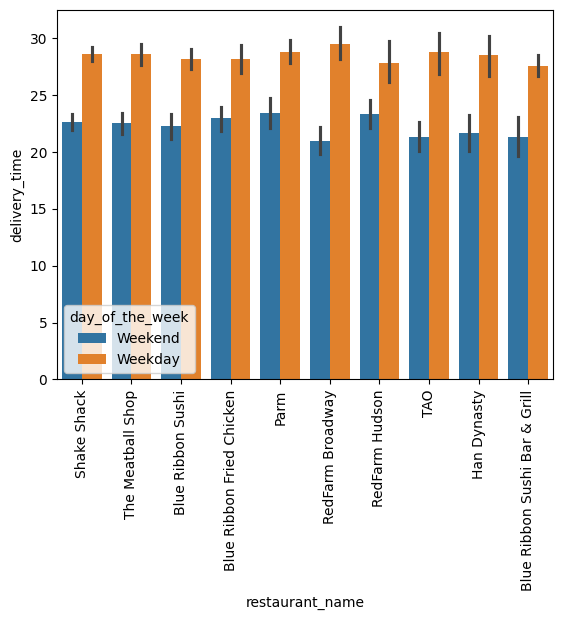

In [ ]:
sns.barplot(data = data, x = 'restaurant_name', y='delivery_time', hue = 'day_of_the_week', order = data.restaurant_name.value_counts().iloc[:10].index)
plt.xticks(rotation=90)
plt.show()

**Food delivery time is observed to be faster on weekends** in all restaurants.

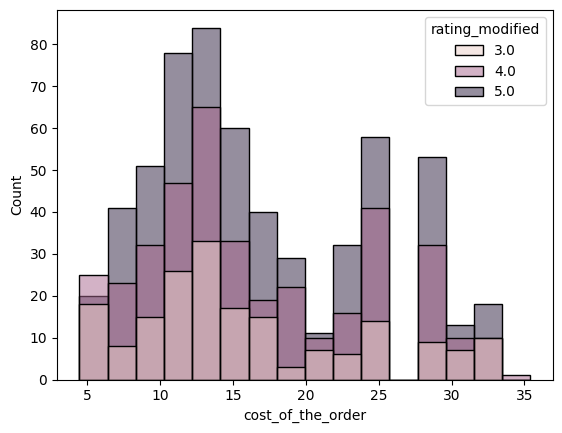

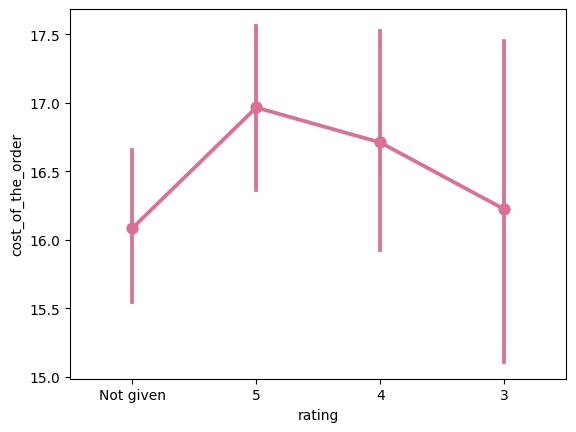

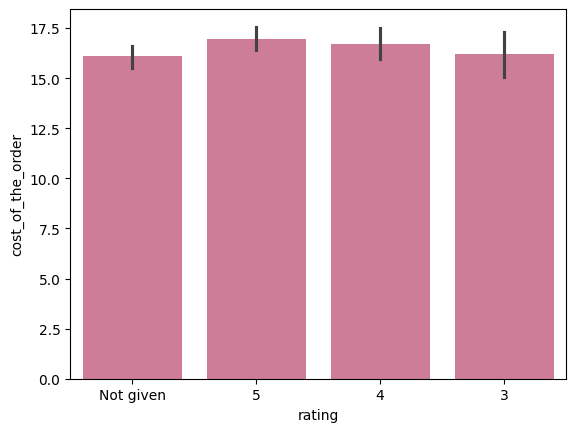

In [ ]:
sns.histplot(data = data, x = 'cost_of_the_order', hue = 'rating_modified')
plt.show()
sns.pointplot(data = data, x ='rating', y = 'cost_of_the_order',color='palevioletred',order=['Not given','5','4','3'])
plt.show()
sns.barplot(data = data, x = 'rating', y = 'cost_of_the_order',color='palevioletred',order=['Not given','5','4','3'])
plt.show()

High rating inidicates high mean order cost.

### **Relationship between Customer, Restaurant and Number of orders placed**

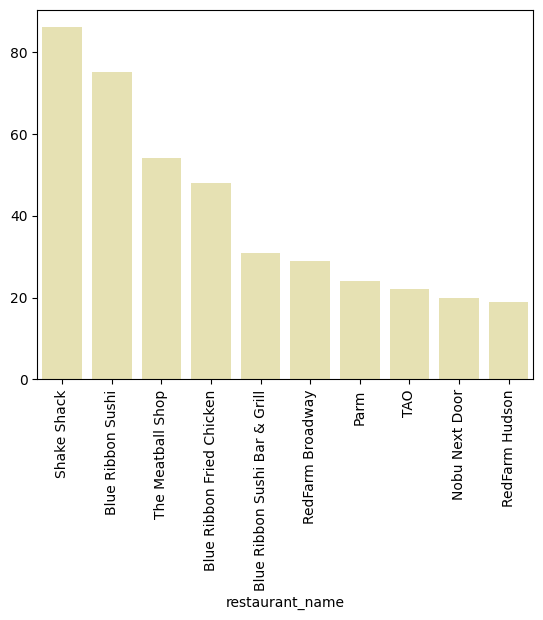

In [ ]:
# Find restaurants with repeated orders by the same customer and count occurrences
repeated_orders=data[data.duplicated(subset=['customer_id', 'restaurant_name'], keep=False)]['restaurant_name'].value_counts()
sns.barplot(x=repeated_orders.index, y=repeated_orders.values,order=repeated_orders.iloc[:10].index,color='palegoldenrod')
plt.xticks(rotation=90)
plt.show()

The above graph shows the top 10 restaurants with the highest number of repeat orders from customers who have previously ordered from the same restaurant

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
filter=data.groupby('restaurant_name')['rating_modified'] #group the data by restaurant name
filter_data=filter.agg(['count','mean']) #find the count and mean of ratings for each restaurant
filter_data.loc[(filter_data['count']>50)&(filter_data['mean']>4)] #filter only the restaurants with rating count more than 50 and average rating more than 4


,count,mean
restaurant_name,,
Blue Ribbon Fried Chicken,64,4.328125
Blue Ribbon Sushi,73,4.219178
Shake Shack,133,4.278195
The Meatball Shop,84,4.511905


#### Observations:
The restaurants that fulfil the criteria to get the promotional offer are: **Blue Ribbon Fried Chicken, Blue Ribbon Sushi, Shake Shack and The Meatball Shop**

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
def net_revenue_calculate(cost):
  if cost>20:
    return cost*0.25
  elif cost>5:
    return cost*0.15
  else:
    return 0

data['revenue']=data['cost_of_the_order'].apply(net_revenue_calculate)
data['revenue'].sum()


6166.303

#### Observations:
The net revenue generated by the company across all orders is 6166.3 dollars

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
data['total time']=data['food_preparation_time']+data['delivery_time']
data[data['total time']>60].shape[0]/data.shape[0]*100

10.537407797681771

#### Observations:
The percentage of orders that take more than 60 minutes of total delivery time is 10.54 %

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
data.groupby('day_of_the_week')['delivery_time'].mean()

,delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


#### Observations:
The average **delivery time on weekends is shorter** than weekdays.

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  The number of orders is higher on weekends than weekdays.
*  Weekend delivery is faster than weekdays.
*  American cuisine is the most popular choice among customers, with Japanese and Italian cuisine coming in second and third. Customer preferences for cuisine remain consistent between weekdays and weekends.
*   15 restaurants account for more than 50% of the total orders.
*   40 % of orders are not rated.
*   70 % of the orders are priced below 20 dollars.
*   65 % of customers in the dataset made only one order.
*   28% of restaurants in the dataset received only one order.
*   Food preparation time is the same on both weekends and weekdays.
*   Out of 178 restaurants, only 27 restaurants are receiving more orders on weekdays than the weekends. Other restaurants are receiving more orders on weekends.









### Recommendations:

*  Encourage customers to rate their orders which will help to understand overall customer satsifaction and restaurants with more ratings tend to attract more customers hence more orders
*   Take steps to ensure faster delivery on weekdays.
*   Work with new restaurants specializing in American, Japanese and Italian cuisines.
*   Around 10% of the orders take more than an hour to get delivered from the time of placing the order. Further investigation needs to be done to understand the reason behind the delay.

